# Data Preprocessing 3 - Advanced Concepts

Three techniques that round out a real preprocessing toolkit but are missing from the fundamentals notebooks:

1. **Outlier detection** - IQR, z-score, and `IsolationForest`
2. **Datetime feature extraction** - pulling structure out of timestamps, including cyclical encoding
3. **Target & frequency encoding** - leakage-safe encoding for high-cardinality categoricals

> Builds on **`01_pandas_fundamentals.ipynb`** and **`02_sklearn_preprocessing.ipynb`**.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)

titanic = sns.load_dataset('titanic')
print('Titanic shape:', titanic.shape)

Titanic shape: (891, 15)


## 1) Outlier Detection

Notebook 02 showed `RobustScaler`, which *resists* outliers - but never actually **found** them. Detecting outliers matters: they can be data-entry errors to drop, or rare-but-real events to keep. We demonstrate three methods on Titanic `fare`, which is strongly right-skewed.

### 1.1) IQR method

The classic rule: anything below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is an outlier. Distribution-free and easy to explain.

In [2]:
fare = titanic['fare'].dropna()

Q1, Q3 = fare.quantile(0.25), fare.quantile(0.75)
IQR = Q3 - Q1
low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
iqr_outliers = fare[(fare < low) | (fare > high)]

print(f'Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}')
print(f'Bounds: [{low:.2f}, {high:.2f}]')
print(f'IQR outliers: {len(iqr_outliers)} of {len(fare)} '
      f'({100*len(iqr_outliers)/len(fare):.1f}%)')

Q1=7.91  Q3=31.00  IQR=23.09
Bounds: [-26.72, 65.63]
IQR outliers: 116 of 891 (13.0%)


### 1.2) Z-score method

Flag points more than 3 standard deviations from the mean: `|(x - mean) / std| > 3`. Assumes roughly normal data, so it flags fewer points than IQR on skewed columns like `fare`.

In [3]:
z = (fare - fare.mean()) / fare.std()
z_outliers = fare[z.abs() > 3]
print(f'Z-score (|z|>3) outliers: {len(z_outliers)} '
      f'({100*len(z_outliers)/len(fare):.1f}%)')

Z-score (|z|>3) outliers: 20 (2.2%)


### 1.3) IsolationForest (multivariate)

IQR and z-score look at **one column at a time**. `IsolationForest` is a model that isolates outliers across **multiple features at once** - it flags rows that are unusual *jointly*, which single-column rules miss. Here we use `age` + `fare` together.

In [4]:
from sklearn.ensemble import IsolationForest

feat = titanic[['age', 'fare']].dropna()
iso = IsolationForest(contamination=0.05, random_state=42)
pred = iso.fit_predict(feat)          # -1 = outlier, 1 = inlier
feat = feat.assign(outlier=(pred == -1))
print(f'IsolationForest flagged {feat.outlier.sum()} of {len(feat)} rows '
      f'({100*feat.outlier.mean():.1f}%)')

IsolationForest flagged 36 of 714 rows (5.0%)


### 1.4) Visual comparison

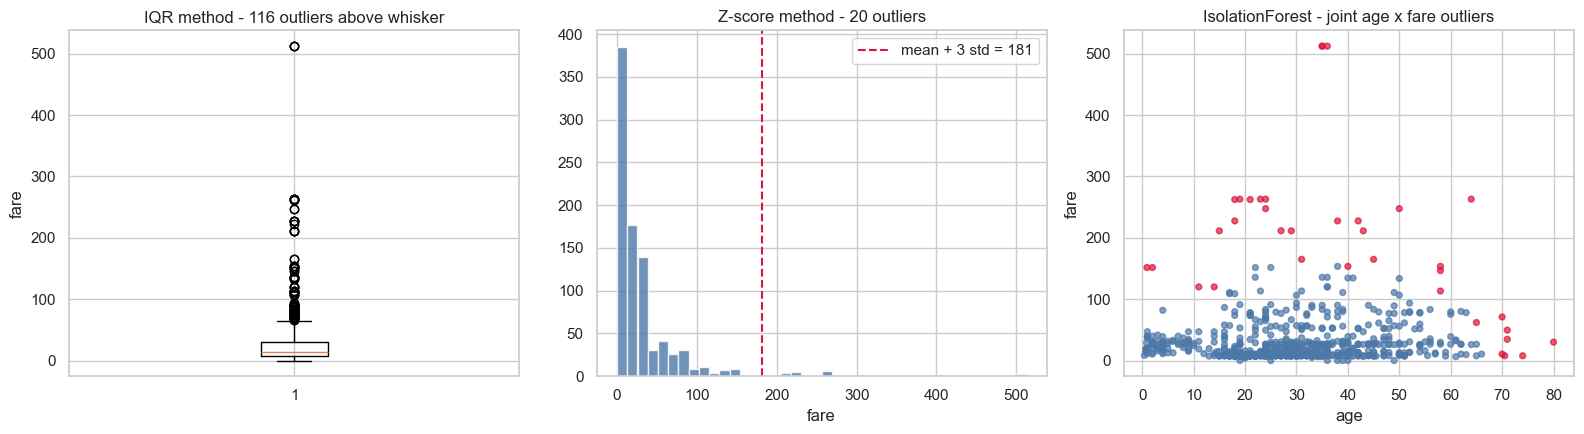

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Boxplot: the IQR whiskers *are* the 1.5*IQR bounds
axes[0].boxplot(fare, vert=True)
axes[0].set_title(f'IQR method - {len(iqr_outliers)} outliers above whisker')
axes[0].set_ylabel('fare')

# Histogram with z-score cutoff
axes[1].hist(fare, bins=40, color='#4C78A8', alpha=0.8)
cut = fare.mean() + 3 * fare.std()
axes[1].axvline(cut, color='crimson', ls='--', label=f'mean + 3 std = {cut:.0f}')
axes[1].set_title(f'Z-score method - {len(z_outliers)} outliers')
axes[1].set_xlabel('fare'); axes[1].legend()

# IsolationForest in 2D feature space
colors = feat.outlier.map({False: '#4C78A8', True: 'crimson'})
axes[2].scatter(feat.age, feat.fare, c=colors, s=18, alpha=0.7)
axes[2].set_title('IsolationForest - joint age x fare outliers')
axes[2].set_xlabel('age'); axes[2].set_ylabel('fare')

plt.tight_layout(); plt.show()

**Takeaway:** the three methods disagree on purpose. IQR is generous on skewed data, z-score is conservative, and IsolationForest catches *combinations* (young passenger + very high fare) that neither single-column rule sees. Detect first; **then** decide to cap, drop, or keep - never delete blindly.

## 2) Datetime Feature Extraction

A raw timestamp is nearly useless to a model as-is. The signal lives in its **parts** - hour of day, day of week, month - and in their **cyclical** nature. Titanic has no dates, so we switch to seaborn's `taxis` dataset (NYC taxi trips) which has real pickup timestamps.

In [6]:
taxis = sns.load_dataset('taxis')
taxis['pickup'] = pd.to_datetime(taxis['pickup'])
print('taxis shape:', taxis.shape)
taxis[['pickup', 'distance', 'fare']].head()

taxis shape: (6433, 14)


,pickup,distance,fare
0,2019-03-23 20:21:09,1.60,7.0
1,2019-03-04 16:11:55,0.79,5.0
2,2019-03-27 17:53:01,1.37,7.5
3,2019-03-10 01:23:59,7.70,27.0
4,2019-03-30 13:27:42,2.16,9.0


### 2.1) Extract calendar parts with the `.dt` accessor

Once a column is real `datetime64`, pandas exposes every component through `.dt`.

In [7]:
dt = taxis['pickup'].dt
taxis['year']       = dt.year
taxis['month']      = dt.month
taxis['day']        = dt.day
taxis['hour']       = dt.hour
taxis['dayofweek']  = dt.dayofweek          # 0 = Monday
taxis['is_weekend'] = dt.dayofweek.isin([5, 6]).astype(int)

taxis[['pickup', 'hour', 'dayofweek', 'is_weekend']].head()

,pickup,hour,dayofweek,is_weekend
0,2019-03-23 20:21:09,20,5,1
1,2019-03-04 16:11:55,16,0,0
2,2019-03-27 17:53:01,17,2,0
3,2019-03-10 01:23:59,1,6,1
4,2019-03-30 13:27:42,13,5,1


### 2.2) Cyclical encoding

Hour `23` and hour `0` are one hour apart, but as plain integers the model sees them as maximally far apart (23 vs 0). Encoding the value on a circle with **sine and cosine** fixes this - `23:00` and `00:00` land right next to each other.

In [8]:
def cyclical(series, period):
    radians = 2 * np.pi * series / period
    return np.sin(radians), np.cos(radians)

taxis['hour_sin'], taxis['hour_cos'] = cyclical(taxis['hour'], 24)
taxis['month_sin'], taxis['month_cos'] = cyclical(taxis['month'], 12)

taxis[['hour', 'hour_sin', 'hour_cos']].drop_duplicates().sort_values('hour').head(8)

,hour,hour_sin,hour_cos
130,0,0.000000,1.000000e+00
3,1,0.258819,9.659258e-01
26,2,0.500000,8.660254e-01
20,3,0.707107,7.071068e-01
163,4,0.866025,5.000000e-01
88,5,0.965926,2.588190e-01
18,6,1.000000,6.123234e-17
13,7,0.965926,-2.588190e-01


### 2.3) Visualizing the extracted signal

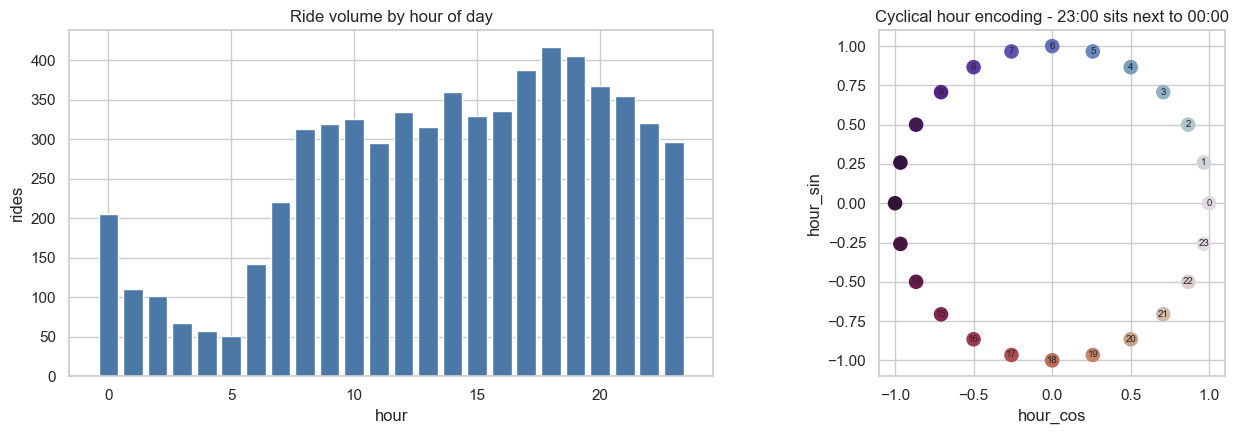

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

rides_by_hour = taxis.groupby('hour').size()
axes[0].bar(rides_by_hour.index, rides_by_hour.values, color='#4C78A8')
axes[0].set_title('Ride volume by hour of day')
axes[0].set_xlabel('hour'); axes[0].set_ylabel('rides')

# The clock laid flat: each hour placed on a circle via (cos, sin)
h = np.arange(24)
axes[1].scatter(np.cos(2*np.pi*h/24), np.sin(2*np.pi*h/24), c=h, cmap='twilight', s=90)
for hh in h:
    axes[1].annotate(str(hh), (np.cos(2*np.pi*hh/24), np.sin(2*np.pi*hh/24)),
                     ha='center', va='center', fontsize=7)
axes[1].set_title('Cyclical hour encoding - 23:00 sits next to 00:00')
axes[1].set_xlabel('hour_cos'); axes[1].set_ylabel('hour_sin')
axes[1].set_aspect('equal')

plt.tight_layout(); plt.show()

## 3) Target & Frequency Encoding

One-hot encoding (notebook 02) explodes into one column per category - painful when a feature has dozens of values. Two compact alternatives replace each category with a single number:

- **Frequency encoding** - how often the category appears
- **Target encoding** - the mean target value for that category

Target encoding is powerful but **leaks** if you compute the mean over the whole dataset, so it must be fit on training data only. We use Titanic `embark_town` and `deck` (`survived` is the target).

In [10]:
from sklearn.model_selection import train_test_split

df = titanic[['embark_town', 'deck', 'survived']].dropna(subset=['embark_town']).copy()
df['deck'] = df['deck'].astype('object').fillna('Unknown')

X = df[['embark_town', 'deck']]
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
print('Cardinality  -> embark_town:', X['embark_town'].nunique(),
      '| deck:', X['deck'].nunique())

Cardinality  -> embark_town: 3 | deck: 8


### 3.1) Frequency encoding

Map each category to its frequency **learned from the training set**, then apply that same map to test.

In [11]:
freq = X_train['deck'].value_counts(normalize=True)
deck_freq_train = X_train['deck'].map(freq)
deck_freq_test  = X_test['deck'].map(freq).fillna(0)   # unseen category -> 0

pd.DataFrame({'deck': X_train['deck'], 'freq_encoded': deck_freq_train}).drop_duplicates().head()

,deck,freq_encoded
828,Unknown,0.791291
453,C,0.054054
516,F,0.013514
748,D,0.028529
742,B,0.055556


### 3.2) Target encoding the leaky way vs the safe way

First the **wrong** way (mean over the full data) to see how optimistic it looks, then sklearn's `TargetEncoder`, which uses internal cross-fitting so a row's own target never feeds its own encoding.

In [12]:
# WRONG: mean computed over ALL rows leaks the target
leaky = df.groupby('embark_town')['survived'].mean()
print('Leaky full-data survival rate by town:')
print(leaky.round(3).to_string())

Leaky full-data survival rate by town:
embark_town
Cherbourg      0.554
Queenstown     0.390
Southampton    0.337


In [13]:
from sklearn.preprocessing import TargetEncoder

enc = TargetEncoder(random_state=42)
X_train_te = enc.fit_transform(X_train, y_train)   # cross-fitted on train only
X_test_te  = enc.transform(X_test)

out = pd.DataFrame(X_train_te, columns=['embark_town_te', 'deck_te'], index=X_train.index)
out.insert(0, 'embark_town', X_train['embark_town'].values)
out.drop_duplicates('embark_town').head()

,embark_town,embark_town_te,deck_te
828,Queenstown,0.408492,0.293743
238,Southampton,0.332596,0.300641
453,Cherbourg,0.514042,0.657139


### 3.3) One-hot vs target encoding: column count

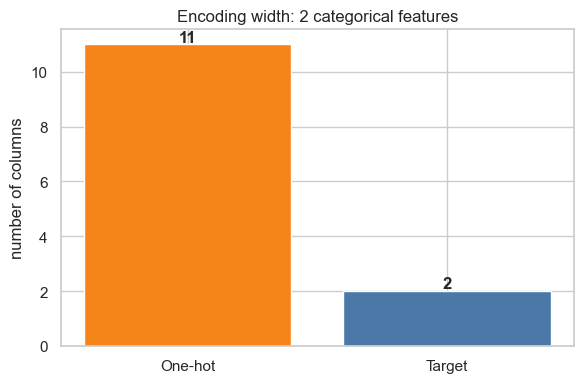

One-hot produced 11 columns; target encoding produced 2.


In [14]:
onehot_cols = pd.get_dummies(X_train).shape[1]
target_cols = X_train_te.shape[1]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['One-hot', 'Target'], [onehot_cols, target_cols],
       color=['#F58518', '#4C78A8'])
for i, v in enumerate([onehot_cols, target_cols]):
    ax.text(i, v + 0.1, str(v), ha='center', fontweight='bold')
ax.set_ylabel('number of columns')
ax.set_title('Encoding width: 2 categorical features')
plt.tight_layout(); plt.show()

print(f'One-hot produced {onehot_cols} columns; target encoding produced {target_cols}.')

## Summary

| Technique | Use it when | Watch out for |
|---|---|---|
| IQR / z-score outliers | Single skewed numeric column | z-score assumes normality |
| IsolationForest | Multivariate / joint outliers | Set `contamination` deliberately |
| Datetime `.dt` parts | Any timestamp column | Parse to `datetime64` first |
| Cyclical (sin/cos) | Hour, month, weekday | Encode both sin **and** cos |
| Frequency encoding | High-cardinality category | Unseen categories -> fill with 0 |
| Target encoding | High-cardinality + strong target signal | **Leakage** - fit on train only |
